**Introduction**

This jupyter notebook covers the essential building blocks of quantum computing.

**Computational basics**

In quantum computing, the computational basis states are written in Dirac notation as `|0⟩` and `|1⟩`. These are the quantum analogues of classical bits:
- `|0⟩` corresponds to the column vector  
  $$
  \begin{pmatrix}
  1 \\
  0
  \end{pmatrix}
  $$
- `|1⟩` corresponds to the column vector  
  $$
  \begin{pmatrix}
  0 \\
  1
  \end{pmatrix}
  $$
These form an orthonormal basis for the two-dimensional complex Hilbert space $\mathbb{C}^2$.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# State |0⟩
# A qubit starts in |0⟩ by default → no gates needed
qc0 = QuantumCircuit(1)
sv0 = Statevector(qc0)
print("Circuit for |0⟩ state:")
print(qc0.draw())
print("State vector for |0>:")
print(sv0)

# State |1⟩
# Apply the Pauli-X (NOT) gate to flip |0⟩ → |1⟩
qc1 = QuantumCircuit(1)
qc1.x(0)
sv1 = Statevector(qc1)
print("\nCircuit for |1⟩ state:")
print(qc1.draw())
print("State vector for |1>:")
print(sv1)

Circuit for |0⟩ state:
   
q: 
   
State vector for |0>:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Circuit for |1⟩ state:
   ┌───┐
q: ┤ X ├
   └───┘
State vector for |1>:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


**Plus, minus states and arbitrary rotation**

In [ ]:
import numpy as np

# |+⟩ state: apply Hadamard to |0⟩
qc_plus = QuantumCircuit(1)
qc_plus.h(0)
sv_plus = Statevector(qc_plus)
print("State vector for |+⟩:")
print(sv_plus.draw('text'))

# |−⟩ state: apply X then Hadamard
qc_minus = QuantumCircuit(1)
qc_minus.x(0)
qc_minus.h(0)
sv_minus = Statevector(qc_minus)
print("\nState vector for |−⟩:")
print(sv_minus.draw('text'))

# Arbitrary rotations: aoply rx, ry, rz
qc_rot = QuantumCircuit(1)
qc_rot.rx(np.pi / 3, 0)   # Rotate around X-axis by 60°
qc_rot.ry(np.pi / 4, 0)   # Rotate around Y-axis by 45°
qc_rot.rz(np.pi / 6, 0)   # Rotate around Z-axis by 30°
sv_rot = Statevector(qc_rot)
print("\nState vector after Rx(60°) → Ry(45°) → Rz(30°):")
print(sv_rot)

print("\nCircuits:")
print("|+⟩ :", qc_plus.draw())
print("|−⟩ :", qc_minus.draw())
print("Rot :", qc_rot.draw())

State vector for |+⟩:
[0.70710678+0.j,0.70710678+0.j]

State vector for |−⟩:
[ 0.70710678+0.j,-0.70710678+0.j]

State vector after Rx(60°) → Ry(45°) → Rz(30°):
Statevector([0.82236317-0.02226003j, 0.43967974-0.36042341j],
            dims=(2,))

Circuits:
|+⟩ :    ┌───┐
q: ┤ H ├
   └───┘
|−⟩ :    ┌───┐┌───┐
q: ┤ X ├┤ H ├
   └───┘└───┘
Rot :    ┌─────────┐┌─────────┐┌─────────┐
q: ┤ Rx(π/3) ├┤ Ry(π/4) ├┤ Rz(π/6) ├
   └─────────┘└─────────┘└─────────┘


Representing statevectors in the Bloch sphere

AttributeError: 'Bloch' object has no attribute 'add_state'

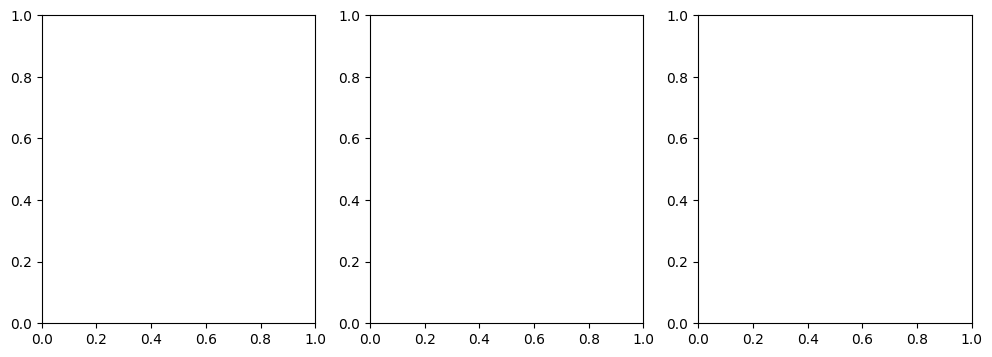

In [24]:
from qiskit.visualization.bloch import Bloch
import matplotlib.pyplot as plt

states = [sv_plus, sv_minus, sv_rot]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, state in zip(axes, states):
    b = Bloch(axes=ax)
    b.add_state(state)
    b.render()

plt.show()